In [20]:
import pandas as pd
import numpy as np
import os

# Set of Occupations that will be used to compare between time points

In [21]:
data_root_url = '../data/anthropic_index/release_2025_03_27/'

def merge_onet_soc_data(data_root_url=data_root_url) -> pd.DataFrame:
    """
    Merges O*NET task statements with SOC (Standard Occupational Classification) data
    based on major group codes.
    
    Returns:
        pd.DataFrame: Merged DataFrame containing O*NET data with SOC major group titles
        and up
    """

    # Read and process O*NET data
    onet_df = pd.read_csv(os.path.join(data_root_url,"onet_task_statements.csv"))
    onet_df["soc_major_group"] = onet_df["O*NET-SOC Code"].str[:2]
    
    # Read and process SOC data
    soc_df = pd.read_csv(os.path.join(data_root_url, "SOC_Structure.csv"))
    soc_df = soc_df.dropna(subset=['Major Group'])
    soc_df["soc_major_group"] = soc_df["Major Group"].str[:2]
    
    # Merge datasets
    merged_df = onet_df.merge(
        soc_df[['soc_major_group', 'SOC or O*NET-SOC 2019 Title']],
        on='soc_major_group',
        how='left'
    )

    # Update cluster mappings to include data from the merged_df
    merged_df["task_normalized"] = merged_df["Task"].str.lower().str.strip()

    # Some tasks are included multiple times, so we need to count the number of occurrences per task
    merged_df["n_occurrences"] = merged_df.groupby("task_normalized")["Title"].transform("nunique")


    return merged_df

task_occupations_df = merge_onet_soc_data()

In [22]:
# Read and process O*NET data
onet_df = pd.read_csv(os.path.join(data_root_url,"onet_task_statements.csv"))
onet_df["soc_major_group"] = onet_df["O*NET-SOC Code"].str[:2]

# Read and process SOC data
soc_df = pd.read_csv(os.path.join(data_root_url, "SOC_Structure.csv"))
soc_df = soc_df.dropna(subset=['Major Group'])
soc_df["soc_major_group"] = soc_df["Major Group"].str[:2]

In [23]:
onet_df[onet_df['O*NET-SOC Code'] == '15-1221.00']

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,soc_major_group


In [24]:
task_occupations_df[task_occupations_df['O*NET-SOC Code'] == '15-1221.00']

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,soc_major_group,SOC or O*NET-SOC 2019 Title,task_normalized,n_occurrences


Granularity of the data that will have to be assumed for the function that we will write:
1. Each row has occupation-task information with:
* data on relative frequency (which is defined as the usage RATE globally). Hence, the summation of the task frequency will not add up to 100%. Rather, it will sum up to the usage rate by the people within that occupation globally.
* for each task, it has relative frequency on if it was used for either automation (as a Feedback Loop or Directive) or augmentation (Learning, Task Iteration, Validation).

| Interaction type | Category     | What it means                                                               |
| ---------------- | ------------ | --------------------------------------------------------------------------- |
| Learning         | Augmentation | Human uses AI to gain knowledge or understanding                            |
| Task Iteration   | Augmentation | Human and AI collaboratively refine a task                                  |
| Validation       | Augmentation | Human uses AI to check or improve their own work                            |
| Directive        | Automation   | Human delegates the task to AI with minimal interaction                     |
| Feedback Loop    | Automation   | AI performs the task while the human mainly provides environmental feedback |

Our goal for data processing is to get occupation level data where we have the relative usage rates per occupation, and the relative frequency of each interaction type.


# 2025 March

Get O*NET and SOC DataFrame. Each task can be mapped to multiple occupations. What we do to solve that problem is to just distribute the task usage equally to the $n$ related occupations

We always need to have:
1. task_mappings_df where the two columns are the task_name and pct usage globally, and 
2. automation_vs_augmentation_with_occupations where for each task, you have the relative frequency for each interaction type

In [25]:
def create_task_ai_interaction_frequencies(
    task_mappings_df: pd.DataFrame,
    auto_aug_task_df: pd.DataFrame,
    task_occupations_df: pd.DataFrame = task_occupations_df,
) -> pd.DataFrame:
    """Create occupation-level AI interaction frequencies from task-level data.

    Combines global task usage, task-to-occupation mappings, and task-level
    automation/augmentation interaction frequencies. Task usage is allocated
    equally across all occupations associated with each task, then normalized
    to produce relative occupation-task frequencies.

    Parameters
    ----------
    task_mappings_df : pd.DataFrame
        Global task usage data. Must contain ``task_name`` and ``pct``, where
        ``pct`` represents the global relative usage of each task.

    auto_aug_task_df : pd.DataFrame
        Task-level automation/augmentation interaction data. Must contain
        ``task_name`` and the relative frequency of each AI interaction type.

    task_occupations_df : pd.DataFrame
        Mapping between tasks and occupations. Must contain
        ``task_normalized`` and ``O*NET-SOC Code``. Each task should have an
        ``n_occurrences`` value indicating the number of occupations associated
        with it.

    Returns
    -------
    pd.DataFrame
        Occupation-level AI interaction frequencies. Contains one row per
        occupation-task combination, with task usage allocated across
        occupations and the interaction-type frequencies attached to each task.
    """
    grouped_with_occupations = task_mappings_df.merge(
        task_occupations_df,
        left_on="task_name",
        right_on="task_normalized",
        how="left",
    )

    # Allocate task usage equally across associated occupations.
    allocated_task_usage = (
        grouped_with_occupations["pct"]
        / grouped_with_occupations["n_occurrences"]
    )

    # Normalize allocated task usage to obtain relative frequency.
    grouped_with_occupations["pct_occ_scaled"] = (
        100 * allocated_task_usage / allocated_task_usage.sum()
    )

    # Attach task-level AI interaction frequencies.
    automation_vs_augmentation_with_tasks = (
        grouped_with_occupations.merge(
            auto_aug_task_df,
            on="task_name",
            how="left",
        )
    )

    relevant_cols = [
    'O*NET-SOC Code',
    'task_name',
    'pct_occ_scaled',
    'feedback_loop',
    'directive',
    'task_iteration',
    'validation',
    'learning',
    'filtered']

    #return automation_vs_augmentation_with_tasks
    return automation_vs_augmentation_with_tasks[relevant_cols]

In [26]:
# per task, get the percent usage
task_mappings_df = pd.read_csv(os.path.join(data_root_url, "task_pct_v2.csv"))
# get the automation v augmentaion per task
auto_aug_task_df = pd.read_csv(os.path.join(data_root_url, "automation_vs_augmentation_by_task.csv"))
automation_vs_augmentation_with_tasks = create_task_ai_interaction_frequencies(task_mappings_df, auto_aug_task_df)

Let:
* $j$ be a job found in SOC database
* $t \in T_j$ as a task belonging to some job $j$
* $k \in K$ as one of the five interaction types with $K =  \{\text{Learning, Task Iteration, Validation, Directive, Feedback Loop}\}$
* $f_t$ as the relative GLOBAL frequency of task $t$
* $I_{t, k}$ as the interaction-type value for task $t$ and interaction type $k$

The overall goal of this whole process is to determine the relative frequency ($R_{j, k}$) of interaction type $k$ for some job $j$.

1. For each job $j$, the total relative frequency of its task is $F_j = \sum_{t \in T_j} f_j$. In other words, $F_j$ is the relative proportion of conversations that are for job $j$.

2. For each interaction type $k$, we calculate the weighted sum across all tasks belonging to job $j$ as $$W_{j, k} = \sum_{t \in T_s} f_t I_{t, k}.$$

3. We calculate the relative frequency $R_{j, k}$ of the interaction type $k$ as the weighted importance all over the total task frequency for job $j$. In other words,
$$R_{j, k} = \frac{W_{j, k}}{F_j}

In [27]:
def create_job_ai_interaction_frequencies(automation_vs_augmentation_with_tasks: pd.DataFrame):
    jobs = automation_vs_augmentation_with_tasks['O*NET-SOC Code'].unique()

    results = {
        'job': [],
        'relative_freq': [],
        'feedback_loop': [],
        'directive': [],
        'task_iteration': [],
        'validation': [],
        'learning': [],
        'filtered': []
    }

    interaction_types = [
        'feedback_loop',
        'directive',
        'task_iteration',
        'validation',
        'learning',
        'filtered'
    ]

    for job in jobs:
        is_job = automation_vs_augmentation_with_tasks['O*NET-SOC Code'] == job
        job_df = automation_vs_augmentation_with_tasks[is_job].copy()

        tot_rel_freq_job = job_df['pct_occ_scaled'].sum()

        results['job'].append(job)
        results['relative_freq'].append(tot_rel_freq_job)

        # Get weighted frequency of each interaction type
        relative_freq_interaction_type = np.zeros(len(interaction_types))

        for i, interaction_type in enumerate(interaction_types):
            weighted_sum = (
                job_df[interaction_type] * job_df["pct_occ_scaled"]
            ).sum()

            relative_freq_interaction_type[i] = weighted_sum

        # Normalize across interaction types
        total = relative_freq_interaction_type.sum()

        if total > 0:
            relative_freq_interaction_type /= total

        # Store one value per interaction type for this job
        for i, interaction_type in enumerate(interaction_types):
            results[interaction_type].append(
                relative_freq_interaction_type[i]
            )

    return pd.DataFrame(results)

soc_ai_measurement_2025_03_df = create_job_ai_interaction_frequencies(automation_vs_augmentation_with_tasks)
soc_ai_measurement_2025_03_df['End'] = pd.Timestamp("2025-03-01")

# 2025 August

In [28]:
def create_task_dataframes(anthropic_filepath, is_latest=False):
    # open the usage data for august 2025
    anthropic_usage_df = pd.read_csv(anthropic_filepath)
    anthropic_global_df = anthropic_usage_df[anthropic_usage_df['geo_id'] == 'GLOBAL']
    task_name = 'cluster_name'
    variable = 'variable'
    anthropic_global_df = anthropic_global_df[[variable, task_name, 'value']]

    # get the task mappings
    task_mappings_df = anthropic_global_df.loc[anthropic_global_df[variable] == 'onet_task_pct', [task_name, 'value']].copy()
    task_mappings_df.columns = ['task_name', 'pct']

    # we have to clean up the automation v augmentation relative frequencies
    auto_aug_task_df = anthropic_global_df.loc[anthropic_global_df[variable] == 'onet_task_collaboration_pct', [task_name, 'value']]
    # separate the string which includes the task and the type and make it a new column
    task = auto_aug_task_df[task_name].str.split('::').apply(lambda task_value : task_value[0])
    auto_aug_task_df['task_name'] = task
    types = auto_aug_task_df[task_name].str.split('::').apply(lambda task_value : task_value[1])
    auto_aug_task_df['type'] = types

    # pivot the dataframe
    auto_aug_task_df = auto_aug_task_df.pivot(columns='type', index='task_name', values='value').fillna(0)
    # combine the none and not classified column into filtered
    auto_aug_task_df['filtered'] = auto_aug_task_df['none'] + auto_aug_task_df['not_classified']
    auto_aug_task_df.rename(columns={'feedback loop':'feedback_loop', 'task iteration':'task_iteration'}, inplace=True)
    interaction_types = [
        'feedback_loop',
        'directive',
        'task_iteration',
        'validation',
        'learning',
        'filtered'
    ]
    auto_aug_task_df = auto_aug_task_df[interaction_types].copy()

    return task_mappings_df, auto_aug_task_df

task_mappings_df, auto_aug_task_df = create_task_dataframes('../data/anthropic_index/release_2025_09_15/data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv')
# now create the 2025 September version of the automation v augmentation tasks
automation_vs_augmentation_with_tasks = create_task_ai_interaction_frequencies(task_mappings_df, auto_aug_task_df)
soc_ai_measurement_2025_08_df = create_job_ai_interaction_frequencies(automation_vs_augmentation_with_tasks).dropna()
soc_ai_measurement_2025_08_df['End'] = pd.Timestamp("2025-08-11")


# 2025 November

In [29]:
task_mappings_df, auto_aug_task_df = create_task_dataframes('../data/anthropic_index/release_2026_01_15/data/intermediate/aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv')
automation_vs_augmentation_with_tasks = create_task_ai_interaction_frequencies(task_mappings_df, auto_aug_task_df)
soc_ai_measurement_2025_11_df = create_job_ai_interaction_frequencies(automation_vs_augmentation_with_tasks).dropna()
soc_ai_measurement_2025_11_df['End'] = pd.Timestamp("2025-11-20")

In [30]:
soc_ai_measurement_2025_11_df.sort_values(by='job')

,job,relative_freq,feedback_loop,directive,task_iteration,validation,learning,filtered,End
168,11-1011.00,0.316141,0.041610,0.246617,0.357578,0.100812,0.198917,0.054465,2025-11-20
437,11-1011.03,0.010374,0.000000,0.000000,0.360825,0.000000,0.000000,0.639175,2025-11-20
500,11-1021.00,0.035507,0.000000,0.373494,0.388554,0.051205,0.000000,0.186747,2025-11-20
396,11-1031.00,0.013048,0.000000,0.180328,0.442623,0.000000,0.000000,0.377049,2025-11-20
395,11-2011.00,0.437314,0.032526,0.314380,0.505503,0.038640,0.072756,0.036195,2025-11-20
...,...,...,...,...,...,...,...,...,...
298,53-6031.00,0.013903,0.000000,0.153846,0.000000,0.000000,0.223077,0.623077,2025-11-20
591,53-6041.00,0.008663,0.000000,0.209877,0.000000,0.000000,0.567901,0.222222,2025-11-20
671,53-6061.00,0.014331,0.000000,0.373134,0.171642,0.000000,0.238806,0.216418,2025-11-20
327,53-7011.00,0.005882,0.000000,0.400000,0.000000,0.000000,0.000000,0.600000,2025-11-20


# February 2026

In [31]:
task_mappings_df, auto_aug_task_df = create_task_dataframes('../data/anthropic_index/release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv')
automation_vs_augmentation_with_tasks = create_task_ai_interaction_frequencies(task_mappings_df, auto_aug_task_df)
soc_ai_measurement_2026_02_df = create_job_ai_interaction_frequencies(automation_vs_augmentation_with_tasks).dropna()
soc_ai_measurement_2026_02_df['End'] = pd.Timestamp("2026-02-12")

soc_ai_measurement_2026_02_df.sort_values(by='job')

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_20687/718429774.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  anthropic_usage_df = pd.read_csv(anthropic_filepath)


,job,relative_freq,feedback_loop,directive,task_iteration,validation,learning,filtered,End
165,11-1011.00,0.392271,0.058404,0.233891,0.344667,0.099260,0.198794,0.064985,2026-02-12
443,11-1011.03,0.007852,0.000000,0.000000,0.260274,0.000000,0.000000,0.739726,2026-02-12
493,11-1021.00,0.050553,0.000000,0.374468,0.334043,0.051064,0.108511,0.131915,2026-02-12
398,11-1031.00,0.030117,0.000000,0.532143,0.257143,0.000000,0.000000,0.210714,2026-02-12
397,11-2011.00,0.555709,0.037550,0.360883,0.441788,0.031937,0.087680,0.040163,2026-02-12
...,...,...,...,...,...,...,...,...,...
673,53-6021.00,0.008927,0.000000,0.373494,0.397590,0.000000,0.000000,0.228916,2026-02-12
285,53-6031.00,0.025492,0.000000,0.341772,0.000000,0.000000,0.198312,0.459916,2026-02-12
596,53-6041.00,0.010326,0.000000,0.166667,0.000000,0.000000,0.614583,0.218750,2026-02-12
674,53-6061.00,0.014198,0.000000,0.386364,0.159091,0.000000,0.196970,0.257576,2026-02-12


# August 2026

In [32]:
anthropic_2026_df = pd.read_csv('../data/anthropic_index/release_2026_06_26/data/aei_claude_ai_2026-06-26.csv')
global_2026_df = anthropic_2026_df[anthropic_2026_df['geo_id'] == 'GLOBAL']
global_jobs_only_2026_df = global_2026_df[global_2026_df['category_name'] == 'soc_occupation']
interaction_types = [
    'pct',
    'collaboration_feedback_loop_pct',
    'collaboration_directive_pct',
    'collaboration_task_iteration_pct',
    'collaboration_validation_pct',
    'collaboration_learning_pct',
    'collaboration_none_pct',]

global_2026_interaction_types_df = global_jobs_only_2026_df[global_jobs_only_2026_df['metric_id'].isin(interaction_types)]
global_2026_may_interaction_types_df = global_2026_interaction_types_df[global_2026_interaction_types_df['date_end'] == '2026-05-01']
global_2026_june_interaction_types_df = global_2026_interaction_types_df[global_2026_interaction_types_df['date_end'] == '2026-06-01']

In [33]:
soc_ai_measurement_2026_05_df = global_2026_may_interaction_types_df.pivot(columns='metric_id', index='node_external_id', values='value')[interaction_types].reset_index()
soc_ai_measurement_2026_05_df[interaction_types] = soc_ai_measurement_2026_05_df[interaction_types] / 100
soc_ai_measurement_2026_05_df['End'] = pd.Timestamp("2026-05-01")

soc_ai_measurement_2026_06_df = global_2026_june_interaction_types_df.pivot(columns='metric_id', index='node_external_id', values='value')[interaction_types].reset_index()
soc_ai_measurement_2026_06_df['End'] = pd.Timestamp("2026-06-01")
soc_ai_measurement_2026_06_df[interaction_types] = soc_ai_measurement_2026_06_df[interaction_types] / 100

In [41]:
soc_ai_measurement_dfs = [soc_ai_measurement_2025_03_df, soc_ai_measurement_2025_08_df, soc_ai_measurement_2025_11_df, soc_ai_measurement_2026_02_df, soc_ai_measurement_2026_05_df, soc_ai_measurement_2026_06_df]

In [35]:
renamed_columns = ['Code', 'Usage Rate', 'Feedback Loop Rate', 'Directive Rate', 'Task Iteration Rate', 'Validation Rate', 'Learning Rate', 'Filtered Rate', 'End']

for soc_ai_measurement_df in soc_ai_measurement_dfs:
    soc_ai_measurement_df.columns = renamed_columns

In [42]:
overall_soc_ai_measurement_df = pd.concat(soc_ai_measurement_dfs)
overall_soc_ai_measurement_df['End'] = pd.to_datetime(overall_soc_ai_measurement_df['End'])


automation_cols = [
    "Feedback Loop Rate",
    "Directive Rate",
]

augmentation_cols = [
    "Task Iteration Rate",
    "Validation Rate",
    "Learning Rate",
]

overall_soc_ai_measurement_df["Automation Rate"] = overall_soc_ai_measurement_df[automation_cols].sum(axis=1)
overall_soc_ai_measurement_df["Augmentation Rate"] = overall_soc_ai_measurement_df[augmentation_cols].sum(axis=1)



num_present_in_releases = overall_soc_ai_measurement_df['Code'].value_counts()
codes_present_in_all_releases = (num_present_in_releases[num_present_in_releases == 6].index).to_list()

In [37]:
is_present_in_all_releases = overall_soc_ai_measurement_df.Code.isin(codes_present_in_all_releases)
balanaced_soc_ai_measurement_df = overall_soc_ai_measurement_df[is_present_in_all_releases]
balanaced_soc_ai_measurement_df = balanaced_soc_ai_measurement_df.sort_values(by=['Code', 'End']).reset_index(drop=True)

In [38]:
overall_soc_ai_measurement_df

,Code,Usage Rate,Feedback Loop Rate,Directive Rate,Task Iteration Rate,Validation Rate,Learning Rate,Filtered Rate,End,Automation Rate,Augmentation Rate
0,27-2041.04,0.161353,0.015554,0.351912,0.418017,0.069994,0.062865,0.081659,2025-03-01,0.367466,0.550875
1,25-1011.00,0.030644,0.005333,0.338524,0.236608,0.090236,0.226899,0.102400,2025-03-01,0.343856,0.553744
2,25-1021.00,0.040624,0.001326,0.350440,0.195447,0.054218,0.248007,0.150561,2025-03-01,0.351767,0.497672
3,25-1022.00,0.085130,0.011132,0.211455,0.149790,0.040932,0.533000,0.053689,2025-03-01,0.222588,0.723723
4,25-1031.00,0.027602,0.001952,0.235976,0.224169,0.022526,0.311858,0.203520,2025-03-01,0.237927,0.558553
...,...,...,...,...,...,...,...,...,...,...,...
735,53-7063.00,0.000000,0.180000,0.580000,0.140000,0.060000,0.020000,0.020000,2026-06-01,0.760000,0.220000
736,53-7064.00,0.000000,0.060600,0.717200,0.171700,0.020200,0.000000,0.030300,2026-06-01,0.777800,0.191900
737,53-7065.00,0.000600,0.061700,0.382200,0.172400,0.042400,0.309500,0.031800,2026-06-01,0.443900,0.524300
738,53-7071.00,0.000000,0.064500,0.871000,0.064500,0.000000,0.000000,0.000000,2026-06-01,0.935500,0.064500


In [ ]:
overall_soc_ai_measurement_df.groupby(['End'])[['Usage Rate', 'Feedback Loop Rate', 'Directive Rate', 'Task Iteration Rate', 'Validation Rate', 'Learning Rate', 'Filtered Rate']].mean()

,Usage Rate,Feedback Loop Rate,Directive Rate,Task Iteration Rate,Validation Rate,Learning Rate,Filtered Rate
End,,,,,,,
2025-03-01,0.133333,0.022521,0.209536,0.158585,0.013961,0.238000,0.356063
2025-08-11,0.143062,0.021595,0.284168,0.141722,0.024350,0.172823,0.355341
2025-11-20,0.138504,0.025468,0.238593,0.176048,0.020818,0.165362,0.373711
2026-02-12,0.138122,0.026055,0.243081,0.166457,0.021056,0.188783,0.354569
2026-05-01,0.002632,0.151467,0.346658,0.269020,0.034773,0.165534,0.032548
2026-06-01,0.002666,0.157987,0.339800,0.274791,0.035023,0.159458,0.032941



[Release derivation] Distinct 'End' dates found: 6
   2025-03-01
   2025-08-11
   2025-11-20
   2026-02-12
   2026-05-01
   2026-06-01

[Release derivation] Mapping used:
   2025-03-01 -> March 2025
   2025-08-11 -> August 2025
   2025-11-20 -> November 2025
   2026-02-12 -> February 2026
   2026-05-01 -> May 2026
   2026-06-01 -> June 2026
[Check] Max |automation_rate - recomputed|: 0.0
[Check] Max |augmentation_rate - recomputed|: 0.0

SECTION 1: DATA AND GROUPING VALIDATION
Distinct SOC major-group codes found: ['11', '13', '15', '17', '19', '21', '23', '25', '27', '29', '31', '33', '35', '37', '39', '41', '43', '45', '47', '49', '51', '53']
Occupations with unmapped/unknown SOC major group: 0
Occupations mapped to more than one group (should be 0): 0

Occupations present in all 6 releases (balanced panel): 432
Occupations dropped (not present in all releases): 610

Occupations per occupation group (balanced panel):
occupation_group
Education, Training, and Library                 

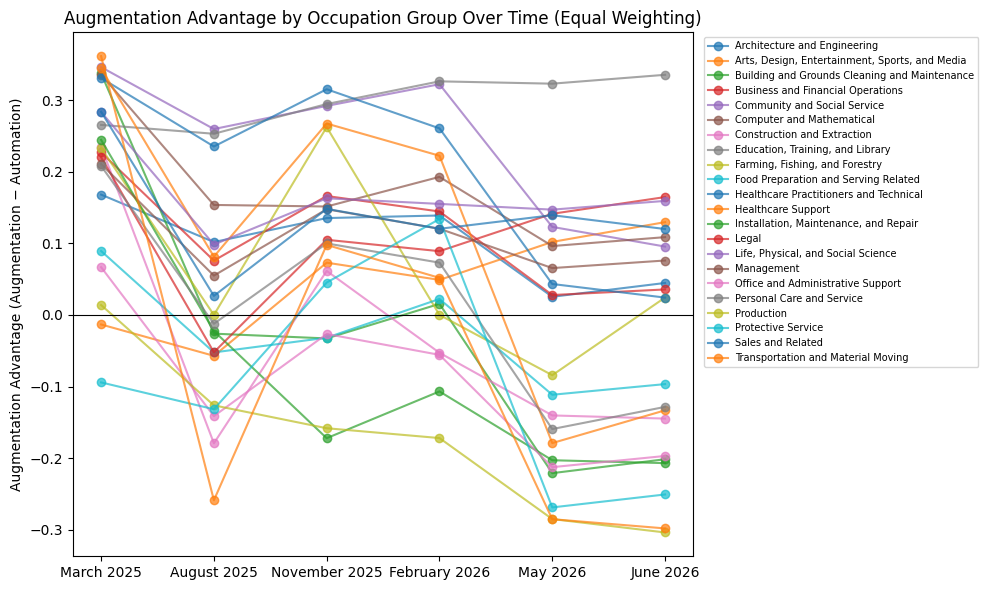

In [45]:
"""
H1: Across occupation groups, AI interaction is becoming more augmentative
relative to automative over time.

Primary unit of analysis: SOC MAJOR OCCUPATION GROUP (2-digit SOC prefix), not
individual occupation. Uses overall_soc_ai_measurement_df as input.

Adjust the COLS mapping below to match your actual column names, then run
top to bottom (script is organized into the same sections as the final report).
"""

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# =============================================================================
# 0. CONFIG — map your actual dataframe column names to the standardized names
#    used throughout this script. Edit the VALUES (right side) only.
# =============================================================================
COLS = {
    "soc_code":            "Code",
    "usage_rate":          "Usage Rate",
    "feedback_loop_rate":  "Feedback Loop Rate",
    "directive_rate":      "Directive Rate",
    "task_iteration_rate": "Task Iteration Rate",
    "validation_rate":     "Validation Rate",
    "learning_rate":       "Learning Rate",
    "filtered_rate":       "Filtered Rate",
    "automation_rate":     "Automation Rate",
    "augmentation_rate":   "Augmentation Rate",
    "end_date":            "End",   # release is DERIVED from this — see below
}

RELEASE_ORDER = [
    "March 2025", "August 2025", "November 2025",
    "February 2026", "May 2026", "June 2026",
]

df_raw = overall_soc_ai_measurement_df.copy()
df_raw = df_raw.rename(columns={v: k for k, v in COLS.items()})

# --- Derive `release` from the `End` (end date) column ----------------------
# There is no explicit release column in the source data. `End` is assumed to
# be the measurement-period end date tied to each of the six releases. We
# parse it, take the distinct values, sort chronologically, and assign the
# six release labels in order. This assumes exactly 6 distinct end-dates.
# INSPECT the printout below before trusting the rest of the script.
df_raw["end_date_parsed"] = pd.to_datetime(df_raw["end_date"], errors="coerce")

n_bad_dates = df_raw["end_date_parsed"].isna().sum() - df_raw["end_date"].isna().sum()
if n_bad_dates > 0:
    print(f"[Warning] {n_bad_dates} 'End' values could not be parsed as dates. "
          f"Inspect df_raw['end_date'].unique() before proceeding.")

distinct_end_dates = sorted(df_raw["end_date_parsed"].dropna().unique())
print(f"\n[Release derivation] Distinct 'End' dates found: {len(distinct_end_dates)}")
for d in distinct_end_dates:
    print(f"   {pd.Timestamp(d).date()}")

if len(distinct_end_dates) != len(RELEASE_ORDER):
    print(f"[Warning] Found {len(distinct_end_dates)} distinct end-dates but expected "
          f"{len(RELEASE_ORDER)} releases. The release mapping below will be WRONG if this "
          f"count doesn't match — fix RELEASE_ORDER or inspect the date values above before trusting results.")

date_to_release = {d: RELEASE_ORDER[i] for i, d in enumerate(distinct_end_dates) if i < len(RELEASE_ORDER)}
df_raw["release"] = df_raw["end_date_parsed"].map(date_to_release)

print("\n[Release derivation] Mapping used:")
for d, r in date_to_release.items():
    print(f"   {pd.Timestamp(d).date()} -> {r}")

# Recompute Automation/Augmentation from components to guarantee consistency
# with the definitions in the brief (does not overwrite source data, just
# derives the analysis columns used below).
df_raw["automation_rate_calc"] = df_raw["feedback_loop_rate"] + df_raw["directive_rate"]
df_raw["augmentation_rate_calc"] = (
    df_raw["task_iteration_rate"] + df_raw["validation_rate"] + df_raw["learning_rate"]
)

# Sanity check vs. dataset's own automation/augmentation columns, if present
if "automation_rate" in df_raw.columns:
    diff_auto = (df_raw["automation_rate"] - df_raw["automation_rate_calc"]).abs()
    diff_aug = (df_raw["augmentation_rate"] - df_raw["augmentation_rate_calc"]).abs()
    print("[Check] Max |automation_rate - recomputed|:", diff_auto.max())
    print("[Check] Max |augmentation_rate - recomputed|:", diff_aug.max())

df_raw["automation_rate"] = df_raw["automation_rate_calc"]
df_raw["augmentation_rate"] = df_raw["augmentation_rate_calc"]
df_raw["augmentation_advantage"] = df_raw["augmentation_rate"] - df_raw["automation_rate"]

df_raw["release"] = pd.Categorical(df_raw["release"], categories=RELEASE_ORDER, ordered=True)
df_raw["time_idx"] = df_raw["release"].cat.codes  # 0..5 numeric time trend

# =============================================================================
# 1. DATA AND GROUPING VALIDATION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 1: DATA AND GROUPING VALIDATION")
print("=" * 80)

# --- 1a. SOC major group mapping -------------------------------------------
# Standard 2023 SOC major group prefixes -> broad occupation-group labels.
SOC_MAJOR_GROUPS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Education, Training, and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

def extract_major_group_code(soc_code):
    """Extract the 2-digit SOC major-group prefix from a SOC code string."""
    if pd.isna(soc_code):
        return None
    s = str(soc_code).strip()
    digits = s.split("-")[0]
    digits = "".join(ch for ch in digits if ch.isdigit())
    return digits[:2] if len(digits) >= 2 else None

df_raw["soc_major_code"] = df_raw["soc_code"].apply(extract_major_group_code)
df_raw["occupation_group"] = df_raw["soc_major_code"].map(SOC_MAJOR_GROUPS)

unmapped = df_raw[df_raw["occupation_group"].isna()]
n_unmapped_codes = unmapped["soc_code"].nunique()
print(f"Distinct SOC major-group codes found: {sorted(df_raw['soc_major_code'].dropna().unique())}")
print(f"Occupations with unmapped/unknown SOC major group: {n_unmapped_codes}")
if n_unmapped_codes > 0:
    print("  Sample unmapped SOC codes:", unmapped["soc_code"].dropna().unique()[:10])
    print("  These rows are EXCLUDED from group-level analysis below (not silently reassigned).")

df_grouped_src = df_raw[df_raw["occupation_group"].notna()].copy()

# Each occupation should map to exactly one group by construction (SOC code -> single prefix).
occ_group_counts = df_grouped_src.groupby("soc_code")["occupation_group"].nunique()
multi_group_occs = occ_group_counts[occ_group_counts > 1]
print(f"Occupations mapped to more than one group (should be 0): {len(multi_group_occs)}")

# --- 1b. Balanced panel ------------------------------------------------------
releases_per_occ = df_grouped_src.groupby("soc_code")["release"].nunique()
n_releases_total = len(RELEASE_ORDER)
balanced_occ_codes = releases_per_occ[releases_per_occ == n_releases_total].index
df_bal = df_grouped_src[df_grouped_src["soc_code"].isin(balanced_occ_codes)].copy()

print(f"\nOccupations present in all {n_releases_total} releases (balanced panel): {len(balanced_occ_codes)}")
print(f"Occupations dropped (not present in all releases): {df_grouped_src['soc_code'].nunique() - len(balanced_occ_codes)}")

# --- 1c. Occupations per group, insufficient-observation groups ------------
group_occ_counts = df_bal.groupby("occupation_group")["soc_code"].nunique().sort_values(ascending=False)
print("\nOccupations per occupation group (balanced panel):")
print(group_occ_counts.to_string())

MIN_OCC_PER_GROUP = 3  # threshold for "insufficient observations" — adjust if needed
thin_groups = group_occ_counts[group_occ_counts < MIN_OCC_PER_GROUP]
print(f"\nGroups with fewer than {MIN_OCC_PER_GROUP} occupations (flagged, not dropped):")
print(thin_groups.to_string() if len(thin_groups) else "  None")

n_groups = df_bal["occupation_group"].nunique()
print(f"\nTotal occupation groups in balanced panel: {n_groups}")

# =============================================================================
# 2. AGGREGATE AT OCCUPATION-GROUP x RELEASE LEVEL (two weighting schemes)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 2/3: GROUP x RELEASE AGGREGATION (equal-weight & usage-weighted)")
print("=" * 80)

def weighted_avg(x, w):
    w = np.asarray(w, dtype=float)
    if w.sum() == 0 or np.isnan(w.sum()):
        return np.nan
    return np.average(x, weights=w)

def aggregate_group_release(data, weight_col=None):
    """Aggregate to (occupation_group, release). weight_col=None => equal weight."""
    records = []
    for (grp, rel), sub in data.groupby(["occupation_group", "release"], observed=True):
        if weight_col is None:
            auto = sub["automation_rate"].mean()
            aug = sub["augmentation_rate"].mean()
            usage = sub["usage_rate"].mean()
            filt = sub["filtered_rate"].mean()
        else:
            w = sub[weight_col]
            auto = weighted_avg(sub["automation_rate"], w)
            aug = weighted_avg(sub["augmentation_rate"], w)
            usage = weighted_avg(sub["usage_rate"], w)
            filt = weighted_avg(sub["filtered_rate"], w)
        records.append({
            "occupation_group": grp,
            "release": rel,
            "automation_rate": auto,
            "augmentation_rate": aug,
            "augmentation_advantage": aug - auto,
            "usage_rate": usage,
            "filtered_rate": filt,
            "n_occupations": sub["soc_code"].nunique(),
        })
    out = pd.DataFrame(records)
    out["release"] = pd.Categorical(out["release"], categories=RELEASE_ORDER, ordered=True)
    out["time_idx"] = out["release"].cat.codes
    return out.sort_values(["occupation_group", "release"]).reset_index(drop=True)

group_eq = aggregate_group_release(df_bal, weight_col=None)          # equal-occupation weighting
group_uw = aggregate_group_release(df_bal, weight_col="usage_rate")  # usage-weighted

print("\nEqual-weighted group x release table (head):")
print(group_eq.head(10).to_string(index=False))
print("\nUsage-weighted group x release table (head):")
print(group_uw.head(10).to_string(index=False))

# =============================================================================
# 4. GROUP-LEVEL TIME SERIES
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 4: GROUP-LEVEL TIME SERIES (Augmentation Advantage)")
print("=" * 80)

def pivot_advantage(group_df):
    return group_df.pivot(index="occupation_group", columns="release", values="augmentation_advantage")[RELEASE_ORDER]

adv_ts_eq = pivot_advantage(group_eq)
adv_ts_uw = pivot_advantage(group_uw)

print("\nAugmentation Advantage by group over time (EQUAL weighting):")
print(adv_ts_eq.round(3).to_string())
print("\nAugmentation Advantage by group over time (USAGE weighting):")
print(adv_ts_uw.round(3).to_string())

# Optional: quick plot (comment out if running headless without display)
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 6))
    for grp in adv_ts_eq.index:
        ax.plot(RELEASE_ORDER, adv_ts_eq.loc[grp], marker="o", label=grp, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Augmentation Advantage (Augmentation − Automation)")
    ax.set_title("Augmentation Advantage by Occupation Group Over Time (Equal Weighting)")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/augmentation_advantage_by_group.png", dpi=150)
    plt.close()
    print("\nSaved chart: /mnt/user-data/outputs/augmentation_advantage_by_group.png")
except Exception as e:
    print("Plotting skipped:", e)

# =============================================================================
# 5. COMPARE GROUPS: start vs end, change, direction
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 5: START vs END COMPARISON TABLE")
print("=" * 80)

FIRST_REL, LAST_REL = RELEASE_ORDER[0], RELEASE_ORDER[-1]

# Threshold for "stable" — defined relative to the pooled SD of period-to-period
# changes in Augmentation Advantage, not chosen arbitrarily post hoc.
def build_change_table(adv_ts):
    diffs_all = adv_ts.diff(axis=1).values.flatten()
    diffs_all = diffs_all[~np.isnan(diffs_all)]
    stable_threshold = 0.5 * np.std(diffs_all)  # half of one typical period-to-period move
    tbl = pd.DataFrame({
        "occupation_group": adv_ts.index,
        "starting_adv_advantage": adv_ts[FIRST_REL].values,
        "ending_adv_advantage": adv_ts[LAST_REL].values,
    })
    tbl["change"] = tbl["ending_adv_advantage"] - tbl["starting_adv_advantage"]
    tbl["direction"] = np.select(
        [tbl["change"] > stable_threshold, tbl["change"] < -stable_threshold],
        ["More augmentative", "More automative"],
        default="Stable",
    )
    return tbl.sort_values("change", ascending=False).reset_index(drop=True), stable_threshold

change_tbl_eq, thr_eq = build_change_table(adv_ts_eq)
change_tbl_uw, thr_uw = build_change_table(adv_ts_uw)

print(f"\nStable-band threshold (equal weighting): ±{thr_eq:.4f}")
print(change_tbl_eq.round(3).to_string(index=False))
print(f"\nStable-band threshold (usage weighting): ±{thr_uw:.4f}")
print(change_tbl_uw.round(3).to_string(index=False))

# =============================================================================
# 6. STATISTICAL TEST — group-level time trend model
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 6: GROUP-LEVEL TIME-TREND MODEL")
print("=" * 80)

def run_fe_time_trend(group_df, label):
    """
    Two-way structure with only 6 time points and ~20-23 groups:
    Augmentation Advantage_gt = alpha_g + beta * time_t + eps_gt
    Fit via OLS with group fixed effects (dummies) and cluster-robust SE by group.
    """
    d = group_df.dropna(subset=["augmentation_advantage"]).copy()
    d["time_idx"] = d["time_idx"].astype(float)
    model = smf.ols("augmentation_advantage ~ time_idx + C(occupation_group)", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["occupation_group"]}
    )
    beta = model.params["time_idx"]
    ci = model.conf_int().loc["time_idx"]
    p = model.pvalues["time_idx"]

    # Effect size: standardize beta by the SD of augmentation_advantage across obs
    sd_y = d["augmentation_advantage"].std()
    std_beta = beta / sd_y if sd_y else np.nan

    print(f"\n--- {label} ---")
    print(f"N groups: {d['occupation_group'].nunique()}, N obs: {len(d)}")
    print(f"beta (per-release change in Augmentation Advantage): {beta:.5f}")
    print(f"95% CI: [{ci[0]:.5f}, {ci[1]:.5f}]")
    print(f"p-value: {p:.5f}")
    print(f"Standardized effect (beta / SD of outcome): {std_beta:.4f}")
    print(f"Total predicted change over 5 release-steps: {beta*5:.4f}")
    return model, beta, ci, p

model_eq, beta_eq, ci_eq, p_eq = run_fe_time_trend(group_eq, "Equal-weighted (fixed effects OLS)")
model_uw, beta_uw, ci_uw, p_uw = run_fe_time_trend(group_uw, "Usage-weighted (fixed effects OLS)")

# Mixed-effects alternative (random intercept per group) — more appropriate
# given only 6 waves and treats groups as a sample rather than fixed dummies.
print("\n--- Mixed-effects (random intercept per group), equal-weighted ---")
try:
    me_model = smf.mixedlm(
        "augmentation_advantage ~ time_idx", data=group_eq.dropna(subset=["augmentation_advantage"]),
        groups=group_eq.dropna(subset=["augmentation_advantage"])["occupation_group"]
    ).fit()
    print(me_model.summary().tables[1])
except Exception as e:
    print("Mixed model failed:", e)

print("""
NOTE on method choice: With only 6 time points, a fixed-effects panel regression
is usable but standard errors should be cluster-robust at the group level (done
above) since observations within a group are correlated over time. A random-
intercept mixed model is reported as a robustness alternative. Neither model
should be over-interpreted given the small number of time periods (T=6);
results here are best read as descriptive of the linear trend component of a
short panel, not as asymptotically well-identified estimates.
""")

# =============================================================================
# 7. DIRECTION OF CHANGE ACROSS GROUPS (simple descriptive test)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 7: DIRECTION OF CHANGE ACROSS GROUPS")
print("=" * 80)

def summarize_direction(change_tbl, label):
    n = len(change_tbl)
    n_pos = (change_tbl["direction"] == "More augmentative").sum()
    n_neg = (change_tbl["direction"] == "More automative").sum()
    n_stable = (change_tbl["direction"] == "Stable").sum()
    print(f"\n[{label}] N groups = {n}")
    print(f"  More augmentative: {n_pos} ({100*n_pos/n:.1f}%)")
    print(f"  More automative:   {n_neg} ({100*n_neg/n:.1f}%)")
    print(f"  Stable:            {n_stable} ({100*n_stable/n:.1f}%)")
    print(f"  Mean change: {change_tbl['change'].mean():.4f}, Median change: {change_tbl['change'].median():.4f}")
    # Sign test / Wilcoxon signed-rank on the change values
    try:
        wstat, wp = stats.wilcoxon(change_tbl["change"])
        print(f"  Wilcoxon signed-rank test (change != 0): stat={wstat:.3f}, p={wp:.4f}")
    except Exception as e:
        print("  Wilcoxon test failed:", e)
    tstat, tp = stats.ttest_1samp(change_tbl["change"], 0)
    print(f"  One-sample t-test (mean change != 0): t={tstat:.3f}, p={tp:.4f}")
    return n_pos, n_neg, n_stable

summarize_direction(change_tbl_eq, "Equal-weighted")
summarize_direction(change_tbl_uw, "Usage-weighted")

# =============================================================================
# 8. THE "MIX" — pattern classification (A-E)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 8: PATTERN CLASSIFICATION")
print("=" * 80)

def classify_pattern(n_pos, n_neg, n_stable, n_total):
    pct_pos = n_pos / n_total
    pct_neg = n_neg / n_total
    if pct_pos >= 0.90:
        return "Pattern A: Almost all groups move toward augmentation"
    elif pct_pos >= 0.60 and pct_neg > 0:
        return "Pattern B: Most groups move toward augmentation, some toward automation"
    elif abs(pct_pos - pct_neg) < 0.15 and (pct_pos + pct_neg) > 0.3:
        return "Pattern C: Roughly even mixture"
    elif pct_neg >= 0.60:
        return "Pattern D: Most groups move toward automation"
    else:
        return "Pattern E: No systematic movement"

for label, tbl in [("Equal-weighted", change_tbl_eq), ("Usage-weighted", change_tbl_uw)]:
    n_pos = (tbl["direction"] == "More augmentative").sum()
    n_neg = (tbl["direction"] == "More automative").sum()
    n_stable = (tbl["direction"] == "Stable").sum()
    pattern = classify_pattern(n_pos, n_neg, n_stable, len(tbl))
    print(f"[{label}] {pattern}  (aug={n_pos}, auto={n_neg}, stable={n_stable}, total={len(tbl)})")

# =============================================================================
# 9. TRANSITIONS: dominance categories (first vs last release)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 9: DOMINANCE TRANSITIONS (first release -> last release)")
print("=" * 80)

# Balanced threshold justified via the same "half a typical move" logic as sec 5,
# but computed on levels (augmentation_advantage), not diffs.
def dominance_category(adv_value, threshold):
    if adv_value > threshold:
        return "Augmentation-dominant"
    elif adv_value < -threshold:
        return "Automation-dominant"
    else:
        return "Balanced"

def transition_table(adv_ts, label):
    level_sd = adv_ts.values.flatten()
    level_sd = level_sd[~np.isnan(level_sd)].std()
    dom_threshold = 0.25 * level_sd  # quarter of one SD of levels, pre-specified rule
    first = adv_ts[FIRST_REL].apply(lambda v: dominance_category(v, dom_threshold))
    last = adv_ts[LAST_REL].apply(lambda v: dominance_category(v, dom_threshold))
    trans = pd.DataFrame({"first_release_category": first, "last_release_category": last})
    ct = pd.crosstab(trans["first_release_category"], trans["last_release_category"])
    print(f"\n[{label}] Balanced-dominance threshold: ±{dom_threshold:.4f}")
    print(ct.to_string())
    return trans, ct

trans_eq, ct_eq = transition_table(adv_ts_eq, "Equal-weighted")
trans_uw, ct_uw = transition_table(adv_ts_uw, "Usage-weighted")

# =============================================================================
# 10. ABSOLUTE VS RELATIVE GROWTH — automation & augmentation trends separately
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 10: AUTOMATION vs AUGMENTATION TRENDS SEPARATELY")
print("=" * 80)

for label, gdf in [("Equal-weighted", group_eq), ("Usage-weighted", group_uw)]:
    auto_start = gdf[gdf["release"] == FIRST_REL]["automation_rate"].mean()
    auto_end = gdf[gdf["release"] == LAST_REL]["automation_rate"].mean()
    aug_start = gdf[gdf["release"] == FIRST_REL]["augmentation_rate"].mean()
    aug_end = gdf[gdf["release"] == LAST_REL]["augmentation_rate"].mean()
    print(f"\n[{label}] Group-average Automation Rate: {auto_start:.4f} -> {auto_end:.4f} "
          f"(Δ={auto_end-auto_start:+.4f})")
    print(f"[{label}] Group-average Augmentation Rate: {aug_start:.4f} -> {aug_end:.4f} "
          f"(Δ={aug_end-aug_start:+.4f})")
    print(f"[{label}] => Augmentation Advantage Δ: {(aug_end-aug_start)-(auto_end-auto_start):+.4f}")

# =============================================================================
# 11. HIGH-AI-USAGE OCCUPATION GROUPS
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 11: HIGH-USAGE OCCUPATION GROUPS")
print("=" * 80)

def high_usage_subset(group_df, top_pct, label):
    # Rank groups by their average usage_rate across all releases
    avg_usage = group_df.groupby("occupation_group")["usage_rate"].mean().sort_values(ascending=False)
    n_top = max(1, int(np.ceil(len(avg_usage) * top_pct)))
    top_groups = avg_usage.head(n_top).index.tolist()
    print(f"\n[{label}] Top {int(top_pct*100)}% by usage = {n_top} groups: {top_groups}")

    sub = group_df[group_df["occupation_group"].isin(top_groups)]
    adv_ts_sub = pivot_advantage(sub)
    tbl, thr = build_change_table(adv_ts_sub)
    print(tbl.round(3).to_string(index=False))
    n_pos = (tbl["direction"] == "More augmentative").sum()
    n_neg = (tbl["direction"] == "More automative").sum()
    print(f"  -> {n_pos}/{len(tbl)} more augmentative, {n_neg}/{len(tbl)} more automative")
    return top_groups, tbl

top10_eq, top10_tbl_eq = high_usage_subset(group_eq, 0.10, "Equal-weighted, top 10% usage")
top20_eq, top20_tbl_eq = high_usage_subset(group_eq, 0.20, "Equal-weighted, top 20% usage")
top10_uw, top10_tbl_uw = high_usage_subset(group_uw, 0.10, "Usage-weighted, top 10% usage")
top20_uw, top20_tbl_uw = high_usage_subset(group_uw, 0.20, "Usage-weighted, top 20% usage")

# =============================================================================
# 12. ROBUSTNESS — leave-one-group-out
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 12: LEAVE-ONE-GROUP-OUT ROBUSTNESS")
print("=" * 80)

def leave_one_out_beta(group_df, label):
    all_groups = group_df["occupation_group"].unique()
    results = []
    for g in all_groups:
        sub = group_df[group_df["occupation_group"] != g].dropna(subset=["augmentation_advantage"])
        try:
            m = smf.ols("augmentation_advantage ~ time_idx + C(occupation_group)", data=sub).fit(
                cov_type="cluster", cov_kwds={"groups": sub["occupation_group"]}
            )
            results.append({"excluded_group": g, "beta": m.params["time_idx"], "p_value": m.pvalues["time_idx"]})
        except Exception as e:
            results.append({"excluded_group": g, "beta": np.nan, "p_value": np.nan})
    out = pd.DataFrame(results).sort_values("beta")
    print(f"\n[{label}] Full-sample beta for reference: see Section 6.")
    print(out.round(5).to_string(index=False))
    print(f"Range of beta across leave-one-out runs: [{out['beta'].min():.5f}, {out['beta'].max():.5f}]")
    sign_flip = ((out["beta"] > 0).any() and (out["beta"] < 0).any())
    print(f"Sign of beta flips depending on excluded group: {sign_flip}")
    return out

loo_eq = leave_one_out_beta(group_eq, "Equal-weighted")
loo_uw = leave_one_out_beta(group_uw, "Usage-weighted")

# =============================================================================
# 13. GROUP-LEVEL vs OCCUPATION-LEVEL COMPARISON (heterogeneity check)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 13: OCCUPATION-LEVEL vs GROUP-LEVEL COMPARISON")
print("=" * 80)

occ_level = df_bal.dropna(subset=["augmentation_advantage"]).copy()
occ_model = smf.ols(
    "augmentation_advantage ~ time_idx + C(soc_code)", data=occ_level
).fit(cov_type="cluster", cov_kwds={"groups": occ_level["soc_code"]})
print(f"Occupation-level beta (time trend, occupation fixed effects): {occ_model.params['time_idx']:.5f}, "
      f"p={occ_model.pvalues['time_idx']:.5f}, N occupations={occ_level['soc_code'].nunique()}")
print(f"Group-level beta (equal-weighted): {beta_eq:.5f}, p={p_eq:.5f}")
print(f"Group-level beta (usage-weighted): {beta_uw:.5f}, p={p_uw:.5f}")

# Dispersion comparison: SD of occupation-level slopes vs SD of group-level slopes
def per_unit_slopes(data, unit_col):
    slopes = []
    for u, sub in data.groupby(unit_col, observed=True):
        sub = sub.dropna(subset=["augmentation_advantage"])
        if sub["time_idx"].nunique() < 2:
            continue
        slope = np.polyfit(sub["time_idx"], sub["augmentation_advantage"], 1)[0]
        slopes.append(slope)
    return np.array(slopes)

occ_slopes = per_unit_slopes(df_bal, "soc_code")
grp_slopes = per_unit_slopes(group_eq, "occupation_group")
print(f"\nSD of individual occupation-level slopes: {occ_slopes.std():.5f} (N={len(occ_slopes)})")
print(f"SD of group-level slopes: {grp_slopes.std():.5f} (N={len(grp_slopes)})")
print("If group-level SD << occupation-level SD, aggregation is reducing idiosyncratic noise "
      "as intended (not manufacturing a false pattern) — inspect group-level dispersion above "
      "in Section 5/8 to confirm real heterogeneity is still visible.")

# =============================================================================
# 14. COMPARABILITY OF RELEASES
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 14: RELEASE COMPARABILITY CHECKS")
print("=" * 80)

coverage = df_raw.groupby("release", observed=True)["soc_code"].nunique()
print("\nDistinct occupations per release (full, unbalanced data):")
print(coverage.to_string())

usage_by_release = df_raw.groupby("release", observed=True)["usage_rate"].agg(["mean", "median", "std", "count"])
print("\nUsage Rate distribution per release:")
print(usage_by_release.round(4).to_string())

filtered_by_release = df_raw.groupby("release", observed=True)["filtered_rate"].agg(["mean", "median", "std"])
print("\nFiltered Rate distribution per release (proxy for classification/methodology shifts):")
print(filtered_by_release.round(4).to_string())

if "end_date" in df_raw.columns:
    date_span = df_raw.groupby("release", observed=True)["end_date"].agg(["min", "max"])
    print("\nEnd date range per release:")
    print(date_span.to_string())

print("""
Interpretation guidance: large swings in occupation coverage, Filtered Rate, or
Usage Rate distribution shape between releases suggest changing measurement/
methodology rather than (or in addition to) real behavioral change. Any such
swing found above should be weighed against the beta estimate in Section 6
before treating the trend as a real shift in AI interaction patterns.
""")

# =============================================================================
# SUMMARY TABLES FOR FINAL REPORT (sections 8-9 of the report template)
# =============================================================================
print("\n" + "=" * 80)
print("EVIDENCE SUMMARY TABLE")
print("=" * 80)

summary_rows = [
    ("Overall group-level trend (beta, equal-weighted FE)", f"{beta_eq:+.5f} (p={p_eq:.4f})"),
    ("Overall group-level trend (beta, usage-weighted FE)", f"{beta_uw:+.5f} (p={p_uw:.4f})"),
    ("Mean change in Augmentation Advantage (equal-weighted)", f"{change_tbl_eq['change'].mean():+.4f}"),
    ("Mean change in Augmentation Advantage (usage-weighted)", f"{change_tbl_uw['change'].mean():+.4f}"),
    ("% groups more augmentative (equal-weighted)",
     f"{100*(change_tbl_eq['direction']=='More augmentative').mean():.1f}%"),
    ("% groups more augmentative (usage-weighted)",
     f"{100*(change_tbl_uw['direction']=='More augmentative').mean():.1f}%"),
    ("Leave-one-out beta sign stable (equal-weighted)", f"{not ((loo_eq['beta']>0).any() and (loo_eq['beta']<0).any())}"),
    ("Leave-one-out beta sign stable (usage-weighted)", f"{not ((loo_uw['beta']>0).any() and (loo_uw['beta']<0).any())}"),
]
summary_df = pd.DataFrame(summary_rows, columns=["Evidence", "Result"])
print(summary_df.to_string(index=False))

print("""
Use the printed sections above (1-14) plus this summary table to fill in the
final report structure: data validation, group trends, statistical test,
distribution across groups, dominance transitions, high-usage subgroup results,
robustness, and the final verdict (Supported / Partially supported / No clear
evidence / Contradicted). The script deliberately reports both weighting
schemes, both fixed-effects and mixed-model estimates, and leave-one-out
robustness side by side rather than picking whichever supports H1.
""")

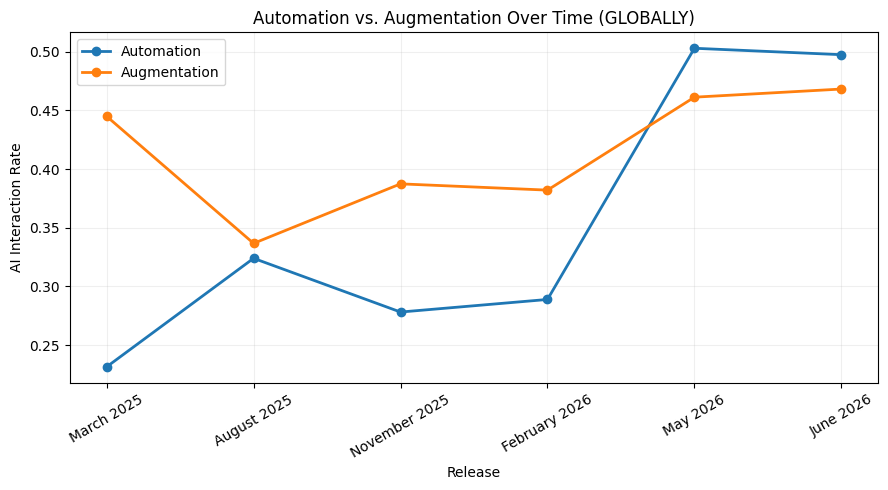

In [66]:
# Average across occupation groups for each release
overall_trend = (
    group_eq.groupby("release", observed=True)[
        ["automation_rate", "augmentation_rate"]
    ]
    .mean()
    .reindex(RELEASE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    RELEASE_ORDER,
    overall_trend["automation_rate"],
    marker="o",
    linewidth=2,
    label="Automation"
)

ax.plot(
    RELEASE_ORDER,
    overall_trend["augmentation_rate"],
    marker="o",
    linewidth=2,
    label="Augmentation"
)

ax.set_xlabel("Release")
ax.set_ylabel("AI Interaction Rate")
ax.set_title("Automation vs. Augmentation Over Time (GLOBALLY)")
ax.legend()
ax.grid(alpha=0.2)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

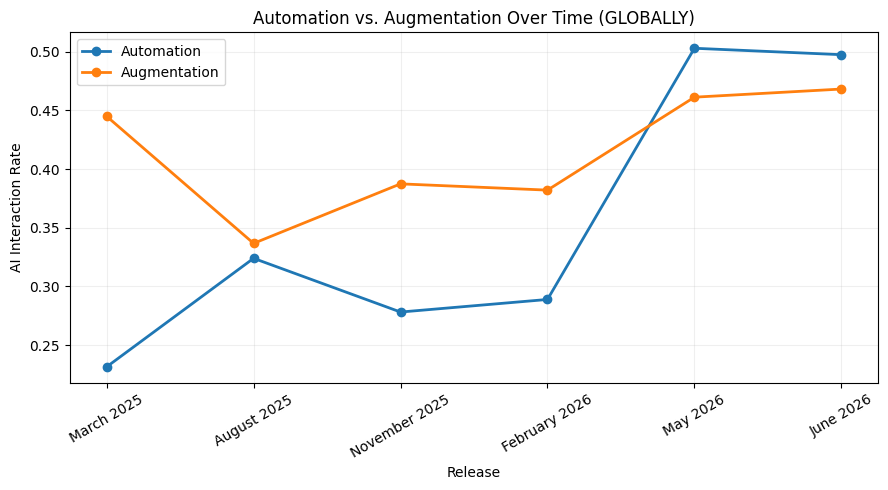

In [67]:
import matplotlib.pyplot as plt

# Average across occupation groups for each release
overall_trend = (
    group_eq.groupby("release", observed=True)[
        ["automation_rate", "augmentation_rate"]
    ]
    .mean()
    .reindex(RELEASE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    RELEASE_ORDER,
    overall_trend["automation_rate"],
    marker="o",
    linewidth=2,
    label="Automation"
)

ax.plot(
    RELEASE_ORDER,
    overall_trend["augmentation_rate"],
    marker="o",
    linewidth=2,
    label="Augmentation"
)

ax.set_xlabel("Release")
ax.set_ylabel("AI Interaction Rate")
ax.set_title("Automation vs. Augmentation Over Time (GLOBALLY)")
ax.legend()
ax.grid(alpha=0.2)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

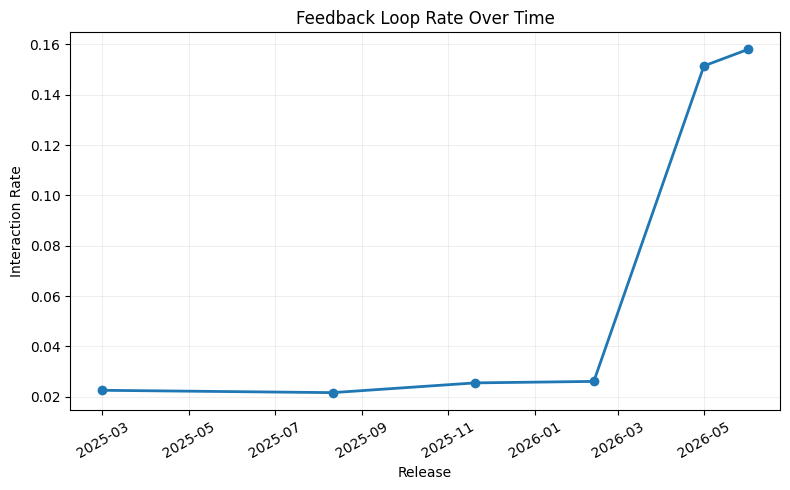

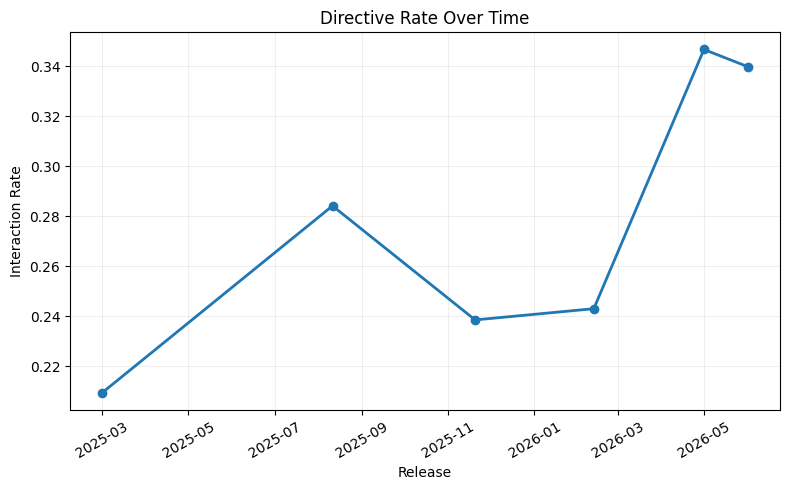

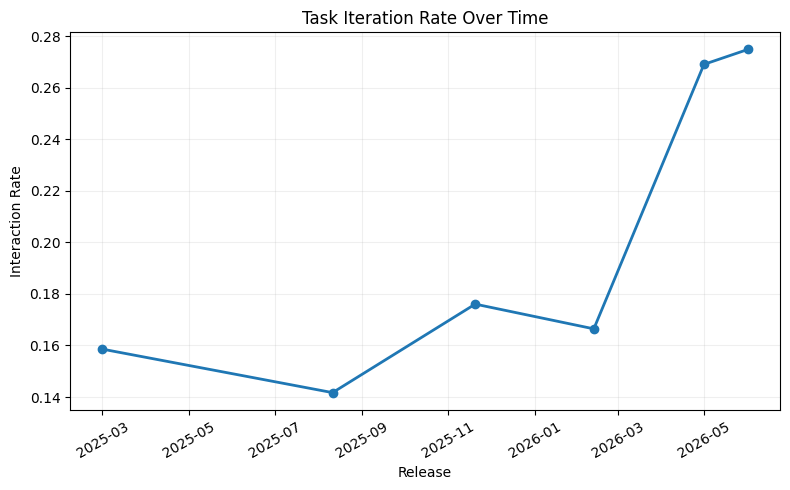

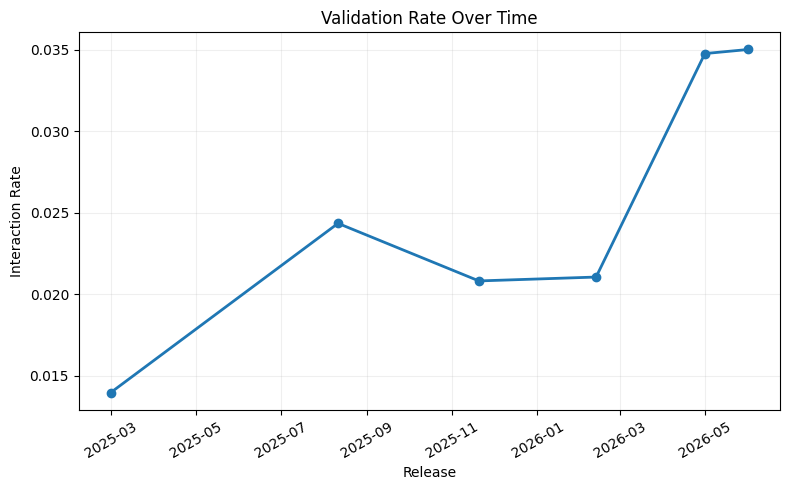

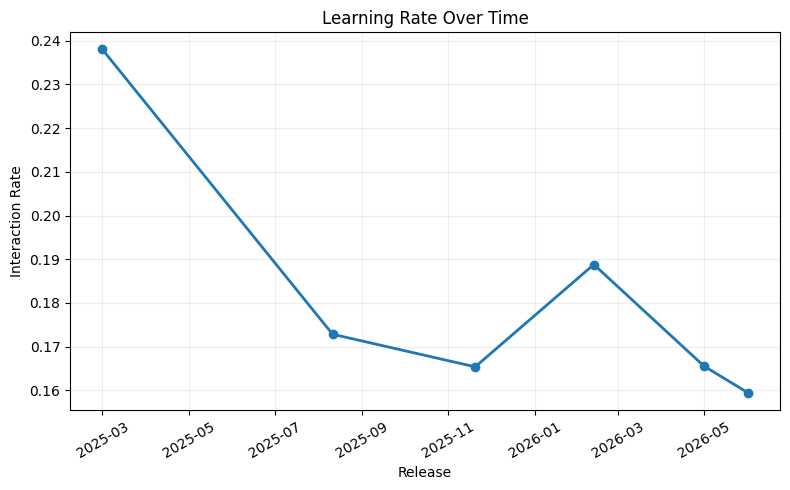

In [68]:
interaction_cols = [
    "Feedback Loop Rate",
    "Directive Rate",
    "Task Iteration Rate",
    "Validation Rate",
    "Learning Rate",
]


for interaction in interaction_cols:
    trend = (
        overall_soc_ai_measurement_df
        .groupby("End")[interaction]
        .mean()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        overall_soc_ai_measurement_df.End.unique(),
        trend,
        marker="o",
        linewidth=2,
    )

    ax.set_xlabel("Release")
    ax.set_ylabel("Interaction Rate")
    ax.set_title(f"{interaction} Over Time")
    ax.grid(alpha=0.2)

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()